In [1]:
# rsync -avz cluster.ies:/mnt/stud/work/phahn/repositories/dal-toolbox/perf_dal_new.db /home/phahn/repositories/dal-toolbox/publications/perf_dal/notebooks/perf_dal_new.db

In [1]:
import mlflow
import numpy as np
import pylab as plt
from collections import defaultdict

In [2]:
# Load in all results
all_acc_curves_strategies = {}

uri = 'sqlite:///perf_dal_new.db'
experiment_name = 'flowers102_ablation'
client = mlflow.tracking.MlflowClient(tracking_uri=uri)
experiment_id = client.get_experiment_by_name(experiment_name).experiment_id
runs_strategies = client.search_runs(experiment_ids=experiment_id)
print('Found {} experiments'.format(len(runs_strategies)))

run_per_strat = defaultdict(list)
acc_curves_strategies = defaultdict(list)
for run in runs_strategies:
    key = run.data.params['al.acq_size']
    dataset = run.data.params['dataset_name']
    run_per_strat[key].append(run)
    accs = [m.value for m in client.get_metric_history(run.info.run_id, 'accuracy')]
    if len(accs) == 21:
        if dataset not in all_acc_curves_strategies:
            all_acc_curves_strategies[dataset] = defaultdict(list)
        all_acc_curves_strategies[dataset][key].append(accs)

Found 20 experiments


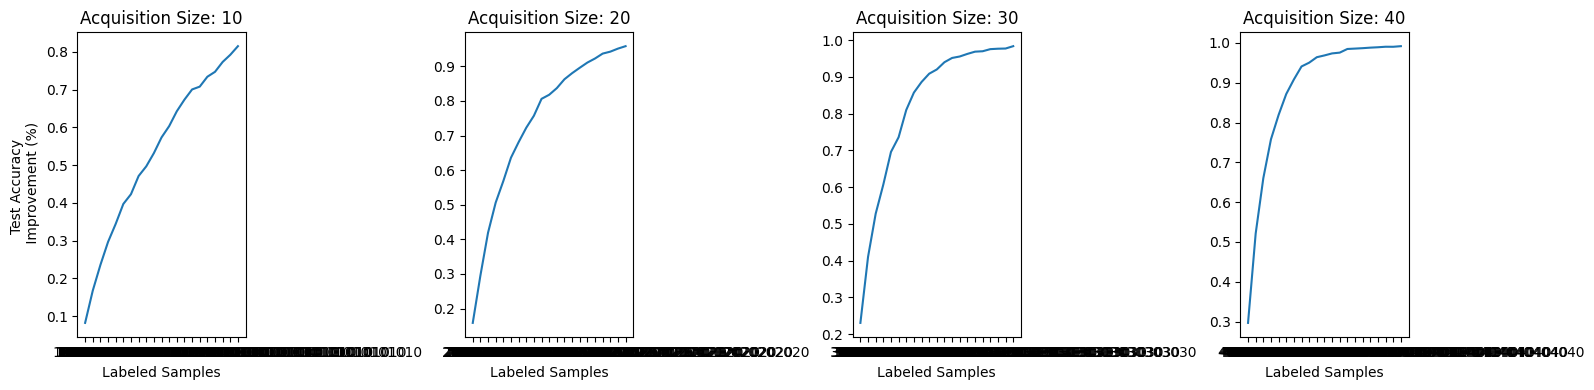

In [11]:
fig, ax = plt.subplots(nrows=1, ncols=4, tight_layout=True, figsize=(16, 4))
dset = 'flowers102'

for i, acqs in enumerate(['10', '20', '30', '40']):
    plt.axes(ax[i])
    x_ticks = [j*acqs for j in range(1, 22)]
    plt.plot(x_ticks, np.mean(all_acc_curves_strategies[dset][acqs], axis=0))
    plt.xlabel('Labeled Samples')
    if i % 4 == 0:
        plt.ylabel('Test Accuracy \n Improvement (%)')
    plt.title('Acquisition Size: '+acqs)
plt.show()